In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import nquad
from astropy.table import Table
import pandas as pd
from matplotlib.path import Path
import math

%matplotlib widget

In [122]:
import uncertainties as u
from uncertainties import ufloat
from uncertainties.umath import *

In [123]:
# area of the sky covered by the fields in square degrees
sqr_degree_sphere = 41252.96125
sqr_degree_fields = 1.5 # VIRCAM tile FOV, we are not using the DECam one because VIRCAM is smaller and we only care about the areas that have both VIRCAM and DECam data
ratio_sky_field = sqr_degree_fields/sqr_degree_sphere

In [124]:
# mass to nr ratio for the halo
mass_to_nr_giant = 343.3778823529412
mass_to_nMSTO = 149.67753846153846

# Computing the normalization

In [125]:
m_halo = ufloat(3.7e8, 1.2e8) # define the mass of the halo between 1 - 45 kpc from Bell et al. 2008

# Einasto profile


Using a more recent halo radial density profile obtained from SEGUE-2 K-giants by Xue et al 2015

In [85]:
def einasto(r, z, nu_0= 1, q = 0.7, r_eff = 15000, n = 3.1):
    r_q = np.sqrt(r**2 + (z/q)**2)
    d_n = 3*n - 1/3 + 0.0079/n
    return nu_0*np.exp(-d_n*((r_q/r_eff)**(1/n) - 1))

In [86]:
def integrand(R, b, l):
    x = R * np.cos(b) * np.cos(l)
    y = R * np.cos(b) * np.sin(l)
    z = R * np.sin(b)
    r = np.sqrt(x**2 + y**2)
    return np.abs(einasto(r, z) * R**2 * np.cos(b))

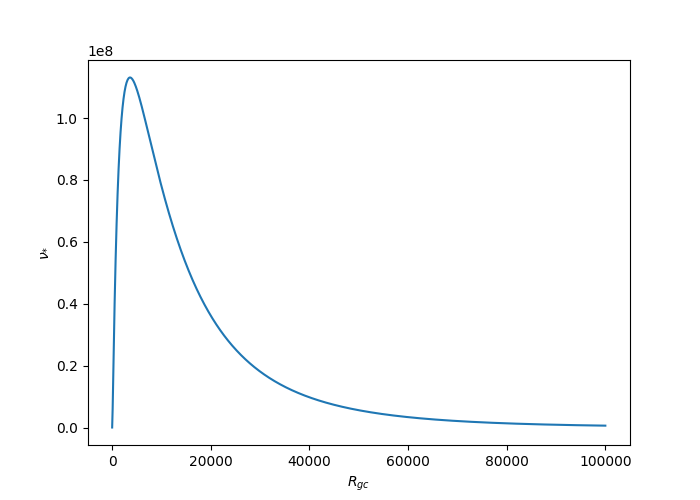

In [87]:
# visualize Einasto profile

plt.figure(figsize=(7, 5))
x = np.linspace(0, 100e3, 1000)
plt.plot(x, integrand(x, 1,1 ))
plt.xlabel(r"$R_{gc}$")
plt.ylabel(r'$\nu_{*}$')
plt.show()

In [102]:
# computing the normalization by integrating over the entire sky with R_gc from 1 to 45 kpc
result, error = nquad(integrand, [[1e3, 45e3], [0, 2*np.pi], [-np.pi/2, np.pi/2]])
norm_einasto = m_halo/result

In [103]:
print(f"Normalization factor for the Einasto profile: {norm_einasto}")

Normalization factor for the Einasto profile: (5.5+/-1.8)e-06


In [117]:
# computing halo mass between 60 and 100 kpc
einasto_outer_halo_mass, einasto_outer_halo_mass_err = nquad(integrand, [[60e3, 100e3], [0, 2*np.pi], [0, np.pi]])
einasto_outer_halo_mass = einasto_outer_halo_mass*norm_einasto

In [118]:
print('The outer halo mass using an Einasto profile is: ', einasto_outer_halo_mass)
# expected counts fields

print('Number of giants in the observed fields: ', ratio_sky_field*einasto_outer_halo_mass/mass_to_nr_giant)


print('Number of nMSTO in the observed fields: ',ratio_sky_field* einasto_outer_halo_mass/mass_to_nMSTO)

The outer halo mass using an Einasto profile is:  (1.9+/-0.6)e+07
Number of giants in the observed fields:  2.0+/-0.6
Number of nMSTO in the observed fields:  4.5+/-1.5


# Using literature normalizations

In [113]:
integral_einasto, integral_einasto_error = nquad(integrand, [[60e3, 100e3], [0, 2*np.pi], [-np.pi/2, np.pi/2]])

In [114]:
norm_goud1998 = 6.4e-5 # Mo/kpc^3
# computing halo mass between 60 and 100 kpc

goud1998_halo_mass = integral_einasto*norm_goud1998

print('The outer halo mass using Goudsmit 1998 profile is: ', goud1998_halo_mass)

print('Number of giants in the observed fields: ', ratio_sky_field*goud1998_halo_mass/mass_to_nr_giant)

print('Number of nMSTO in the observed fields: ',ratio_sky_field* goud1998_halo_mass/mass_to_nMSTO)

The outer halo mass using Goudsmit 1998 profile is:  216267173.0157582
Number of giants in the observed fields:  22.900998354855577
Number of nMSTO in the observed fields:  52.53758446113927
